In [ ]:
from google.colab import userdata
import os
import kagglehub

# Baris 1: ambil token dari Colab Secrets, simpan sebagai environment variable
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# Baris 2: download dataset, hasilnya berupa path folder tempat file tersimpan
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Dataset tersimpan di:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Dataset tersimpan di: /kaggle/input/garbage-classification


In [ ]:
print(os.listdir(path))

['one-indexed-files-notrash_val.txt', 'one-indexed-files-notrash_train.txt', 'Garbage classification', 'garbage classification', 'zero-indexed-files.txt', 'one-indexed-files.txt', 'one-indexed-files-notrash_test.txt']


In [ ]:
print(os.listdir(path + '/Garbage classification'))
print(os.listdir(path + '/garbage classification'))

['Garbage classification']
['Garbage classification']


In [ ]:
inner_path = path + '/Garbage classification/Garbage classification'
print(os.listdir(inner_path))

['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']


In [ ]:
for kelas in os.listdir(inner_path):
    folder_kelas = inner_path + '/' + kelas
    jumlah = len(os.listdir(folder_kelas))
    print(f"{kelas}: {jumlah} gambar")

metal: 410 gambar
glass: 501 gambar
paper: 594 gambar
trash: 137 gambar
cardboard: 403 gambar
plastic: 482 gambar


## **PREPROCESSING**

In [ ]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    inner_path,
    image_size=(224, 224),
    validation_split= 0.2,
    subset='training',
    batch_size=32,
    shuffle=True,
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    inner_path,
    image_size=(224, 224),
    validation_split= 0.2,
    subset='validation',
    batch_size=32,
    seed=42
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_datset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

In [ ]:
val_dataset_eval = tf.keras.utils.image_dataset_from_directory(
    inner_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='validation'
)

# Label Asli
y_true = []

for images, labels in val_dataset_eval:
  y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Prediksi
y_pred_probs = model.predict(val_dataset_eval)
y_pred = np.argmax(y_pred_probs, axis = 1)

print("Akurasi aktual:", accuracy_score(y_true, y_pred))

Found 2527 files belonging to 6 classes.
Using 505 files for validation.
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 875ms/step
Akurasi aktual: 0.19405940594059407


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (224, 224, 3),
    include_top =  False,
    weights = 'imagenet'
)

base_model.trainable = False

print(f"Jumlah layer di MobileNetV2: {len(base_model.layers)}")
print(f"Apakah base_model bisa dilatih? {base_model.trainable}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Jumlah layer di MobileNetV2: 154
Apakah base_model bisa dilatih? False


## **TRAINING**

In [ ]:
# Definisi Custom Layer
@tf.keras.utils.register_keras_serializable()
class PreprocessInput(tf.keras.layers.Layer):
  def call(self, x):
    return tf.keras.applications.mobilenet_v2.preprocess_input(x)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal', input_shape=(224, 224, 3)),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    PreprocessInput(),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input                │ (None, 224, 224, 3)    │             0 │
│ (PreprocessInput)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.3284 - loss: 1.7155 - val_accuracy: 0.5762 - val_loss: 1.2442
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.5218 - loss: 1.2546 - val_accuracy: 0.6832 - val_loss: 0.9945
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.6172 - loss: 1.0288 - val_accuracy: 0.7168 - val_loss: 0.8494
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.6578 - loss: 0.9248 - val_accuracy: 0.7347 - val_loss: 0.7537
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.6978 - loss: 0.8291 - val_accuracy: 0.7525 - val_loss: 0.7003
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7196 - loss: 0.7789 - val_accuracy: 0.7663 - val_loss: 0.6577
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.7448 - loss: 0.7212 - val_accuracy: 0.7861 - val_loss: 0.6217
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7443 - loss: 0.7092 - val_accuracy: 0.8000 - val_loss:

In [ ]:
import os
print(os.path.exists('best_model.keras'))

True


In [ ]:
from google.colab import files
files.download('best_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **EVALUASI**

In [ ]:
import numpy as np

y_true=[]

for images, labels in val_dataset:
  y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Prediksi Model
y_pred_probs = model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 926ms/step


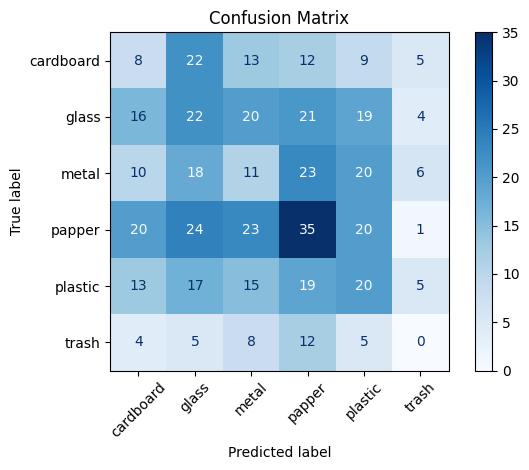

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Nama Kelas
class_names  = ['cardboard', 'glass', 'metal', 'papper', 'plastic', 'trash']

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
print(train_dataset.class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Akurasi aktual:", accuracy_score(y_true, y_pred))
print("\nLaporan per kelas:")
print(classification_report(y_true, y_pred, target_names=class_names))

Akurasi aktual: 0.1900990099009901

Laporan per kelas:
              precision    recall  f1-score   support

   cardboard       0.11      0.12      0.11        69
       glass       0.20      0.22      0.21       102
       metal       0.12      0.12      0.12        88
      papper       0.29      0.28      0.29       123
     plastic       0.22      0.22      0.22        89
       trash       0.00      0.00      0.00        34

    accuracy                           0.19       505
   macro avg       0.16      0.16      0.16       505
weighted avg       0.19      0.19      0.19       505



In [ ]:
y_true = []
y_pred = []

for images, labels in val_dataset_eval:
  y_true.extend(labels.numpy())
  preds  = model.predict(images)
  y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Akurasi aktual:", accuracy_score(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 890ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 893ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Akurasi aktual: 0.8495049504950495


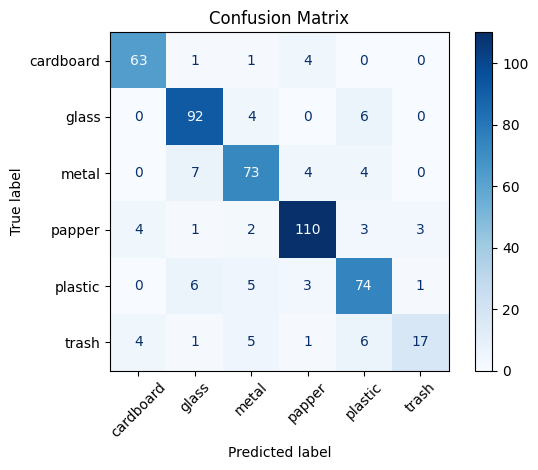

              precision    recall  f1-score   support

   cardboard       0.89      0.91      0.90        69
       glass       0.85      0.90      0.88       102
       metal       0.81      0.83      0.82        88
      papper       0.90      0.89      0.90       123
     plastic       0.80      0.83      0.81        89
       trash       0.81      0.50      0.62        34

    accuracy                           0.85       505
   macro avg       0.84      0.81      0.82       505
weighted avg       0.85      0.85      0.85       505



In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

Tersimpan!


<Figure size 800x600 with 0 Axes>

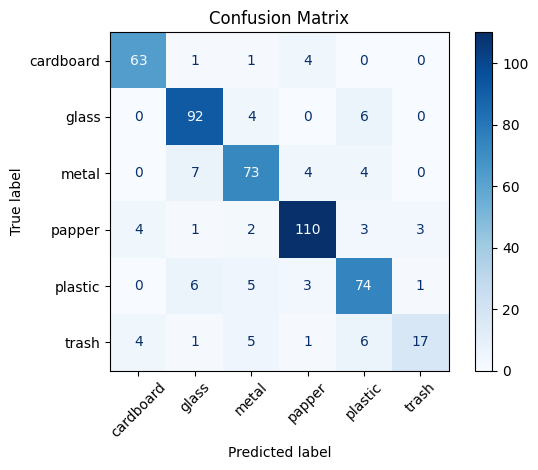

In [ ]:
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
print("Tersimpan!")

In [ ]:
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>